In [1]:
# IMPORT LIBRARIES

import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.model_selection import StratifiedKFold

from sklearn.svm import LinearSVC

from sklearn.metrics import (
    balanced_accuracy_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# LOAD CLEANED DATA

TRAIN_PATH = "../data/interim/train_clean_v1.csv"

train_df = pd.read_csv(TRAIN_PATH)

print("Train Shape :", train_df.shape)

display(train_df.head())

Train Shape : (5000, 2)


,full_text,label
0,pret sekolah mbg tetap anak jajan daan semua s...,Sasaran Penerima
1,mbg bentuk garong duit negara tsm terstruktur-...,Politik
2,pasal 34 ayat 1 undang dasar negara republik i...,Sasaran Penerima
3,makan gizi gratis bikin masyarakat rasa diperh...,Sasaran Penerima
4,presiden ngotot paling kesal kalau mbg kritik ...,Politik


In [3]:
# SPLIT FEATURES & LABELS

X = train_df['full_text']

y = train_df['label']

print("Feature Shape :", X.shape)
print("Label Shape   :", y.shape)

Feature Shape : (5000,)
Label Shape   : (5000,)


In [4]:
# TFIDF VECTORIZER

tfidf = TfidfVectorizer(
    
    ngram_range=(1, 2),
    
    min_df=2,
    
    max_df=0.95,
    
    sublinear_tf=True
)

print("TFIDF initialized.")

TFIDF initialized.


In [5]:
# STRATIFIED KFOLD

skf = StratifiedKFold(
    
    n_splits=5,
    
    shuffle=True,
    
    random_state=42
)

print("StratifiedKFold ready.")

StratifiedKFold ready.


In [6]:
# CROSS VALIDATION

fold_scores = []

oof_predictions = np.zeros(len(X), dtype=object)

for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):
    
    print("=" * 60)
    print(f"FOLD {fold + 1}")
    print("=" * 60)
    
    
    # SPLIT DATA
    
    X_train = X.iloc[train_idx]
    X_valid = X.iloc[valid_idx]
    
    y_train = y.iloc[train_idx]
    y_valid = y.iloc[valid_idx]
    
    
    # TFIDF FIT TRANSFORM
    
    X_train_tfidf = tfidf.fit_transform(X_train)
    
    X_valid_tfidf = tfidf.transform(X_valid)
    
    
    # MODEL
    
    model = LinearSVC(
        class_weight='balanced',
        random_state=42
    )
    
    
    # TRAIN
    
    model.fit(X_train_tfidf, y_train)
    
    
    # PREDICT
    
    predictions = model.predict(X_valid_tfidf)
    
    
    # simpan oof prediction
    oof_predictions[valid_idx] = predictions
    
    
    # EVALUATION
    
    score = balanced_accuracy_score(
        y_valid,
        predictions
    )
    
    fold_scores.append(score)
    
    
    print(f"Balanced Accuracy : {score:.4f}")
    print()

FOLD 1
Balanced Accuracy : 0.5586

FOLD 2
Balanced Accuracy : 0.5806

FOLD 3
Balanced Accuracy : 0.6177

FOLD 4
Balanced Accuracy : 0.6007

FOLD 5
Balanced Accuracy : 0.5765



In [7]:
# OVERALL SCORE

print("=" * 60)
print("CROSS VALIDATION RESULT")
print("=" * 60)

for i, score in enumerate(fold_scores):
    
    print(f"Fold {i+1}: {score:.4f}")

print()

print(f"Mean Balanced Accuracy: {np.mean(fold_scores):.4f}")

print(f"Std Balanced Accuracy : {np.std(fold_scores):.4f}")

CROSS VALIDATION RESULT
Fold 1: 0.5586
Fold 2: 0.5806
Fold 3: 0.6177
Fold 4: 0.6007
Fold 5: 0.5765

Mean Balanced Accuracy: 0.5868
Std Balanced Accuracy : 0.0204


In [8]:
# CLASSIFICATION REPORT

print(
    classification_report(
        y,
        oof_predictions
    )
)

                  precision    recall  f1-score   support

        Anggaran       0.71      0.73      0.72       727
      Distribusi       0.56      0.56      0.56       433
         Ekonomi       0.65      0.67      0.66       145
 Kualitas Pangan       0.67      0.68      0.67      1247
         Lainnya       0.46      0.45      0.45       638
         Politik       0.56      0.53      0.54       792
Sasaran Penerima       0.57      0.61      0.59       507
     Tata Kelola       0.49      0.47      0.48       511

        accuracy                           0.59      5000
       macro avg       0.58      0.59      0.58      5000
    weighted avg       0.59      0.59      0.59      5000



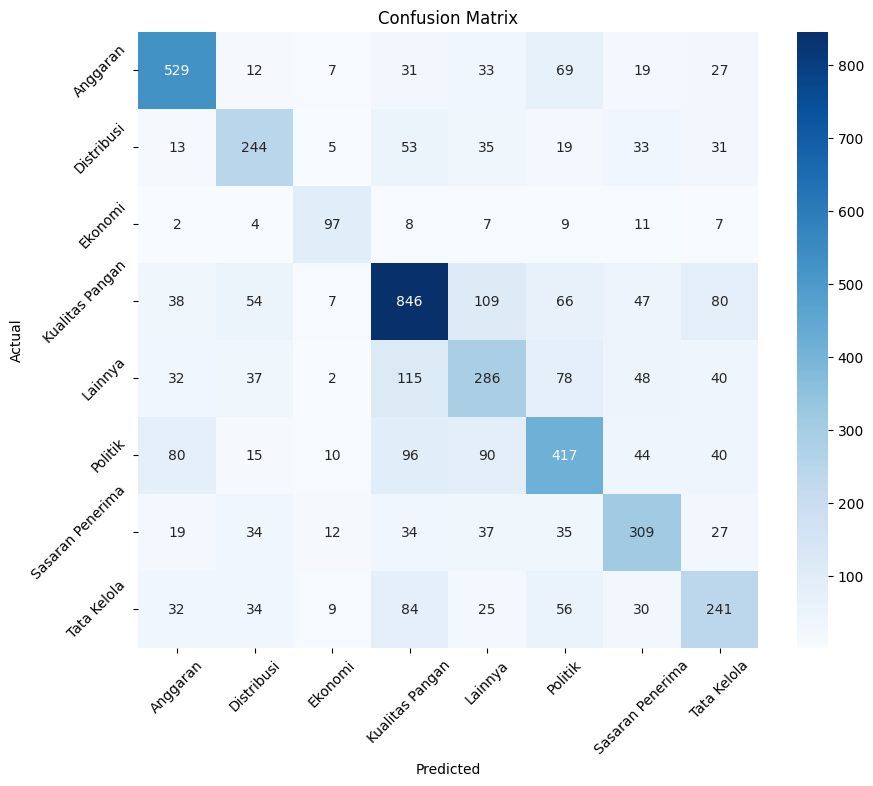

In [9]:
# CONFUSION MATRIX

cm = confusion_matrix(
    y,
    oof_predictions,
    labels=np.unique(y)
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    
    xticklabels=np.unique(y),
    yticklabels=np.unique(y)
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(rotation=45)
plt.yticks(rotation=45)

plt.show()

In [10]:
# OOF PREDICTION DATAFRAME

oof_df = pd.DataFrame({
    
    'full_text': X,
    
    'actual_label': y,
    
    'predicted_label': oof_predictions
})

display(oof_df.head())

,full_text,actual_label,predicted_label
0,pret sekolah mbg tetap anak jajan daan semua s...,Sasaran Penerima,Kualitas Pangan
1,mbg bentuk garong duit negara tsm terstruktur-...,Politik,Lainnya
2,pasal 34 ayat 1 undang dasar negara republik i...,Sasaran Penerima,Anggaran
3,makan gizi gratis bikin masyarakat rasa diperh...,Sasaran Penerima,Sasaran Penerima
4,presiden ngotot paling kesal kalau mbg kritik ...,Politik,Politik


In [11]:
# MISCLASSIFIED SAMPLES

misclassified_df = oof_df[
    
    oof_df['actual_label']
    !=
    oof_df['predicted_label']
]

print("Total Misclassified Samples :")

print(len(misclassified_df))

display(
    misclassified_df.head(20)
)

Total Misclassified Samples :
2031


,full_text,actual_label,predicted_label
0,pret sekolah mbg tetap anak jajan daan semua s...,Sasaran Penerima,Kualitas Pangan
1,mbg bentuk garong duit negara tsm terstruktur-...,Politik,Lainnya
2,pasal 34 ayat 1 undang dasar negara republik i...,Sasaran Penerima,Anggaran
6,polsek teluk nibung monitoring makan gizi grat...,Distribusi,Kualitas Pangan
9,presiden main sandiwara jelas mbg jalan baik s...,Sasaran Penerima,Distribusi
11,buat mbg lah anjayy,Lainnya,Anggaran
12,mbg mulyono bos gemoy,Sasaran Penerima,Politik
13,menag nasaruddin umar sampai program makan giz...,Politik,Lainnya
14,defisit anggar cara buang anggarann hari daera...,Distribusi,Anggaran
15,perlu pimpin blusukan terima lapor abs asal ba...,Distribusi,Sasaran Penerima


In [12]:
# CONFUSION PAIRS

confusion_pairs = (
    
    misclassified_df
    
    .groupby(
        ['actual_label', 'predicted_label']
    )
    
    .size()
    
    .reset_index(name='count')
    
    .sort_values(
        by='count',
        ascending=False
    )
)

display(confusion_pairs.head(20))

,actual_label,predicted_label,count
31,Lainnya,Kualitas Pangan,115
24,Kualitas Pangan,Lainnya,109
38,Politik,Kualitas Pangan,96
39,Politik,Lainnya,90
52,Tata Kelola,Kualitas Pangan,84
27,Kualitas Pangan,Tata Kelola,80
35,Politik,Anggaran,80
32,Lainnya,Politik,78
4,Anggaran,Politik,69
25,Kualitas Pangan,Politik,66
